In [ ]:
import os

PROJECT_ROOT = os.getcwd()
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\kinut\financial-inclusion-zindi\notebooks


In [2]:
PROJECT_ROOT = os.path.dirname(os.getcwd())
os.chdir(PROJECT_ROOT)
print("New root:", os.getcwd())

New root: c:\Users\kinut\financial-inclusion-zindi


In [22]:
import pandas as pd

train_path = os.path.join("data", "raw", "Train.csv")
df = pd.read_csv(train_path)

df.head()


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [23]:
df.info()
df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   country                 23524 non-null  str  
 1   year                    23524 non-null  int64
 2   uniqueid                23524 non-null  str  
 3   bank_account            23524 non-null  str  
 4   location_type           23524 non-null  str  
 5   cellphone_access        23524 non-null  str  
 6   household_size          23524 non-null  int64
 7   age_of_respondent       23524 non-null  int64
 8   gender_of_respondent    23524 non-null  str  
 9   relationship_with_head  23524 non-null  str  
 10  marital_status          23524 non-null  str  
 11  education_level         23524 non-null  str  
 12  job_type                23524 non-null  str  
dtypes: int64(3), str(10)
memory usage: 2.3 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,23524,4,Rwanda,8735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,23524.0,NaN,NaN,NaN,2016.975939,0.847371,2016.0,2016.0,2017.0,2018.0,2018.0
uniqueid,23524,8735,uniqueid_1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bank_account,23524,2,No,20212,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_type,23524,2,Rural,14343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cellphone_access,23524,2,Yes,17454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
household_size,23524.0,NaN,NaN,NaN,3.797483,2.227613,1.0,2.0,3.0,5.0,21.0
age_of_respondent,23524.0,NaN,NaN,NaN,38.80522,16.520569,16.0,26.0,35.0,49.0,100.0
gender_of_respondent,23524,2,Female,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship_with_head,23524,6,Head of Household,12831,NaN,NaN,NaN,NaN,NaN,NaN,NaN


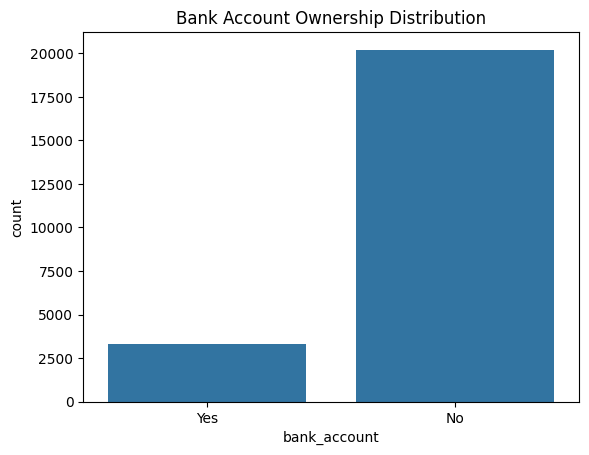

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="bank_account", data=df)
plt.title("Bank Account Ownership Distribution")
plt.show()


In [6]:
os.makedirs("outputs/eda", exist_ok=True)

plt.figure(figsize=(8,5))
sns.countplot(x="bank_account", data=df)
plt.savefig("outputs/eda/bank_account_distribution.png")
plt.close()


In [19]:
# Map 'Yes' -> 1, 'No' -> 0
df['bank_account'] = df['bank_account'].map({'Yes': 1, 'No': 0})

# Check
df['bank_account'].value_counts()

# Encode education level
edu_order = {
    "No formal education":0,
    "Primary education":1,
    "Secondary education":2,
    "Vocational/Specialised training":3,
    "Tertiary education":4
}
df['education_level_num'] = df['education_level'].map(edu_order)

# Group by numeric education level
df.groupby('education_level_num')['bank_account'].mean().sort_values(ascending=False)


education_level_num
3.0    0.570361
4.0    0.510804
2.0    0.232773
1.0    0.085451
0.0    0.038981
Name: bank_account, dtype: float64

In [25]:
# Map 'Yes' -> 1, 'No' -> 0
df['bank_account'] = df['bank_account'].map({'Yes': 1, 'No': 0})

# Quick check
print(df['bank_account'].value_counts())
print(df['bank_account'].value_counts(normalize=True) * 100)

bank_account
0    20212
1     3312
Name: count, dtype: int64
bank_account
0    85.920762
1    14.079238
Name: proportion, dtype: float64


In [28]:
import plotly.express as px

fig = px.histogram(
    df,
    x="bank_account",
    color="bank_account",
    barmode="group",
    text_auto=True,
    labels={
        "bank_account": "Bank Account Status",
        "count": "Number of Respondents"
    },
    title="Bank Account Ownership Distribution"
)

fig.update_layout(
    template="plotly_white",
    xaxis=dict(
        tickmode="array",
        tickvals=[0, 1],
        ticktext=["No Bank Account", "Has Bank Account"]
    ),
    hoverlabel=dict(
        bgcolor="white",
        font_size=13
    )
)

fig.update_traces(
    hovertemplate="<b>Status:</b> %{x}<br><b>Count:</b> %{y}<extra></extra>"
)

fig.show()


In [30]:
import plotly.graph_objects as go
import pandas as pd

# Calculate bank account ownership percentage by country
country_stats = df.groupby('country')['bank_account'].agg(['mean', 'count']).reset_index()
country_stats['percentage'] = country_stats['mean'] * 100
country_stats = country_stats.sort_values('percentage', ascending=False)

# Create interactive bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=country_stats['country'],
    y=country_stats['percentage'],
    text=[f"{val:.1f}%" for val in country_stats['percentage']],
    textposition='outside',
    textfont=dict(size=11, color='#2c3e50'),
    marker=dict(
        color=country_stats['percentage'],
        colorscale='Blues',
        line=dict(color='#34495e', width=1),
        showscale=False
    ),
    hovertemplate=(
        '<b>%{x}</b><br>' +
        'Bank Account Ownership: %{y:.1f}%<br>' +
        'Sample Size: %{customdata:,} respondents<br>' +
        '<extra></extra>'
    ),
    customdata=country_stats['count']
))

# Update layout for professional dashboard appearance
fig.update_layout(
    title=dict(
        text='Bank Account Ownership by Country',
        font=dict(size=22, color='#2c3e50', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title=dict(
            text='Country',
            font=dict(size=14, color='#34495e')
        ),
        tickfont=dict(size=11, color='#34495e'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    yaxis=dict(
        title=dict(
            text='Percentage of Population with Bank Account (%)',
            font=dict(size=14, color='#34495e')
        ),
        tickfont=dict(size=11, color='#34495e'),
        showgrid=True,
        gridcolor='#ecf0f1',
        gridwidth=1,
        range=[0, max(country_stats['percentage']) * 1.1],
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x',
    margin=dict(l=80, r=40, t=80, b=80),
    font=dict(family='Arial, sans-serif'),
    height=600
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_dashboard.html')

# Display the figure
fig.show()

In [55]:
import plotly.graph_objects as go
import pandas as pd

# Calculate detailed statistics by country
country_detailed = df.groupby('country').agg({
    'bank_account': ['sum', 'count', 'mean']
}).reset_index()

# Flatten column names
country_detailed.columns = ['country', 'has_account', 'total_count', 'percentage']
country_detailed['no_account'] = country_detailed['total_count'] - country_detailed['has_account']
country_detailed['percentage'] = country_detailed['percentage'] * 100
country_detailed['no_account_pct'] = 100 - country_detailed['percentage']

# Sort by total count
country_detailed = country_detailed.sort_values('total_count', ascending=False)

# Create stacked bar chart
fig = go.Figure()

# Add bar for those WITH bank account
fig.add_trace(go.Bar(
    name='Has Bank Account',
    x=country_detailed['country'],
    y=country_detailed['has_account'],
    marker=dict(
        color='#00d4aa',
        line=dict(color='#00ffcc', width=2),
        opacity=0.9
    ),
    hovertemplate=(
        '<b style="font-size:14px">%{x}</b><br><br>' +
        '<span style="color:#00d4aa">● Has Bank Account</span><br>' +
        'Count: <b>%{y:,}</b><br>' +
        'Percentage: <b>%{customdata:.1f}%</b><br>' +
        '<extra></extra>'
    ),
    customdata=country_detailed['percentage']
))

# Add bar for those WITHOUT bank account
fig.add_trace(go.Bar(
    name='No Bank Account',
    x=country_detailed['country'],
    y=country_detailed['no_account'],
    marker=dict(
        color='#ff6b6b',
        line=dict(color='#ff8787', width=2),
        opacity=0.9
    ),
    hovertemplate=(
        '<b style="font-size:14px">%{x}</b><br><br>' +
        '<span style="color:#ff6b6b">● No Bank Account</span><br>' +
        'Count: <b>%{y:,}</b><br>' +
        'Percentage: <b>%{customdata:.1f}%</b><br>' +
        '<extra></extra>'
    ),
    customdata=country_detailed['no_account_pct']
))

# Add total count annotations on top of bars
annotations = []
for idx, row in country_detailed.iterrows():
    annotations.append(
        dict(
            x=row['country'],
            y=row['total_count'],
            text=f"<b>{row['total_count']:,}</b>",
            showarrow=False,
            yshift=15,
            font=dict(size=12, color='#ffffff', family='Arial, sans-serif')
        )
    )

# Update layout for dark theme professional dashboard
fig.update_layout(
    title=dict(
        text='<b>Bank Account Ownership Distribution by Country</b>',
        font=dict(size=24, color='#ffffff', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center',
        y=0.97,
        yanchor='top'
    ),
    xaxis=dict(
        title=dict(
            text='<b>Country</b>',
            font=dict(size=16, color='#ffffff'),
        ),
        
        tickfont=dict(size=12, color='#e0e0e0'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#444444',
        tickangle=-45,
        zeroline=False
    ),
    yaxis=dict(
        title=dict(
            text='<b>Total Number of Respondents</b>',
            font=dict(size=16, color='#ffffff'),
        ),
        
        tickfont=dict(size=12, color='#e0e0e0'),
        showgrid=True,
        gridcolor='#333333',
        gridwidth=1,
        showline=True,
        linewidth=2,
        linecolor='#444444',
        zeroline=False
    ),
    barmode='stack',
    plot_bgcolor='#1a1a1a',
    paper_bgcolor='#0d0d0d',
    hovermode='closest',
    hoverlabel=dict(
        bgcolor='#2d2d2d',
        font_size=13,
        font_family='Arial, sans-serif',
        bordercolor='#00d4aa'
    ),
    showlegend=True,
    legend=dict(
        title=dict(
            text='<b>Bank Account Status</b>', 
            font=dict(size=14, color='#ffffff')
        ),
        orientation='v',
        yanchor='top',
        y=0.98,
        xanchor='right',
        x=0.98,
        bgcolor='rgba(45, 45, 45, 0.95)',
        bordercolor='#00d4aa',
        borderwidth=2,
        font=dict(size=13, family='Arial, sans-serif', color='#ffffff')
    ),
    margin=dict(l=100, r=140, t=120, b=150),
    font=dict(family='Arial, sans-serif', color='#ffffff'),
    height=700,
    width=1200,
    annotations=annotations
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_distribution_by_country.html')

# Display the figure
fig.show()

In [56]:
import plotly.graph_objects as go
import pandas as pd

# Calculate detailed statistics by gender
gender_detailed = df.groupby('gender_of_respondent').agg({
    'bank_account': ['sum', 'count', 'mean']
}).reset_index()

# Flatten column names
gender_detailed.columns = ['gender', 'has_account', 'total_count', 'percentage']
gender_detailed['no_account'] = gender_detailed['total_count'] - gender_detailed['has_account']
gender_detailed['percentage'] = gender_detailed['percentage'] * 100
gender_detailed['no_account_pct'] = 100 - gender_detailed['percentage']

# Sort by total count
gender_detailed = gender_detailed.sort_values('total_count', ascending=False)

# Create stacked bar chart
fig = go.Figure()

# Add bar for those WITH bank account
fig.add_trace(go.Bar(
    name='Has Bank Account',
    x=gender_detailed['gender'],
    y=gender_detailed['has_account'],
    marker=dict(
        color='#00d4aa',
        line=dict(color='#00ffcc', width=2),
        opacity=0.9
    ),
    hovertemplate=(
        '<b style="font-size:14px">%{x}</b><br><br>' +
        '<span style="color:#00d4aa">● Has Bank Account</span><br>' +
        'Count: <b>%{y:,}</b><br>' +
        'Percentage: <b>%{customdata:.1f}%</b><br>' +
        '<extra></extra>'
    ),
    customdata=gender_detailed['percentage']
))

# Add bar for those WITHOUT bank account
fig.add_trace(go.Bar(
    name='No Bank Account',
    x=gender_detailed['gender'],
    y=gender_detailed['no_account'],
    marker=dict(
        color='#ff6b6b',
        line=dict(color='#ff8787', width=2),
        opacity=0.9
    ),
    hovertemplate=(
        '<b style="font-size:14px">%{x}</b><br><br>' +
        '<span style="color:#ff6b6b">● No Bank Account</span><br>' +
        'Count: <b>%{y:,}</b><br>' +
        'Percentage: <b>%{customdata:.1f}%</b><br>' +
        '<extra></extra>'
    ),
    customdata=gender_detailed['no_account_pct']
))

# Add total count annotations on top of bars
annotations = []
for idx, row in gender_detailed.iterrows():
    annotations.append(
        dict(
            x=row['gender'],
            y=row['total_count'],
            text=f"<b>{row['total_count']:,}</b>",
            showarrow=False,
            yshift=15,
            font=dict(size=13, color='#ffffff', family='Arial, sans-serif')
        )
    )

# Update layout for dark theme professional dashboard
fig.update_layout(
    title=dict(
        text='<b>Bank Account Ownership Distribution by Gender</b>',
        font=dict(size=24, color='#ffffff', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center',
        y=0.97,
        yanchor='top'
    ),
    xaxis=dict(
        title=dict(
            text='<b>Gender</b>',
            font=dict(size=16, color='#ffffff'),
        ),
        tickfont=dict(size=13, color='#e0e0e0'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#444444',
        zeroline=False
    ),
    
    yaxis=dict(
        title=dict(
            text='<b>Total Number of Respondents</b>',
            font=dict(size=16, color='#ffffff'),
        ),
        
        tickfont=dict(size=12, color='#e0e0e0'),
        showgrid=True,
        gridcolor='#333333',
        gridwidth=1,
        showline=True,
        linewidth=2,
        linecolor='#444444',
        zeroline=False
    ),
    barmode='stack',
    plot_bgcolor='#1a1a1a',
    paper_bgcolor='#0d0d0d',
    hovermode='closest',
    hoverlabel=dict(
        bgcolor='#2d2d2d',
        font_size=13,
        font_family='Arial, sans-serif',
        bordercolor='#00d4aa'
    ),
    showlegend=True,
    legend=dict(
        title=dict(
            text='<b>Bank Account Status</b>', 
            font=dict(size=14, color='#ffffff')
        ),
        orientation='v',
        yanchor='top',
        y=0.98,
        xanchor='right',
        x=0.98,
        bgcolor='rgba(45, 45, 45, 0.95)',
        bordercolor='#00d4aa',
        borderwidth=2,
        font=dict(size=13, family='Arial, sans-serif', color='#ffffff')
    ),
    margin=dict(l=100, r=140, t=120, b=80),
    font=dict(family='Arial, sans-serif', color='#ffffff'),
    height=600,
    width=800,
    annotations=annotations
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_distribution_by_gender.html')

# Display the figure
fig.show()

In [58]:
import plotly.graph_objects as go
import pandas as pd

# Calculate detailed statistics by location type
location_detailed = df.groupby('location_type').agg({
    'bank_account': ['sum', 'count', 'mean']
}).reset_index()

# Flatten column names
location_detailed.columns = ['location_type', 'has_account', 'total_count', 'percentage']
location_detailed['no_account'] = location_detailed['total_count'] - location_detailed['has_account']
location_detailed['percentage'] = location_detailed['percentage'] * 100
location_detailed['no_account_pct'] = 100 - location_detailed['percentage']

# Sort by total count
location_detailed = location_detailed.sort_values('total_count', ascending=False)

# Create stacked bar chart
fig = go.Figure()

# Add bar for those WITH bank account
fig.add_trace(go.Bar(
    name='Has Bank Account',
    x=location_detailed['location_type'],
    y=location_detailed['has_account'],
    marker=dict(
        color='#00d4aa',
        line=dict(color='#00ffcc', width=2),
        opacity=0.9
    ),
    hovertemplate=(
        '<b style="font-size:14px">%{x}</b><br><br>' +
        '<span style="color:#00d4aa">● Has Bank Account</span><br>' +
        'Count: <b>%{y:,}</b><br>' +
        'Percentage: <b>%{customdata:.1f}%</b><br>' +
        '<extra></extra>'
    ),
    customdata=location_detailed['percentage']
))

# Add bar for those WITHOUT bank account
fig.add_trace(go.Bar(
    name='No Bank Account',
    x=location_detailed['location_type'],
    y=location_detailed['no_account'],
    marker=dict(
        color='#ff6b6b',
        line=dict(color='#ff8787', width=2),
        opacity=0.9
    ),
    hovertemplate=(
        '<b style="font-size:14px">%{x}</b><br><br>' +
        '<span style="color:#ff6b6b">● No Bank Account</span><br>' +
        'Count: <b>%{y:,}</b><br>' +
        'Percentage: <b>%{customdata:.1f}%</b><br>' +
        '<extra></extra>'
    ),
    customdata=location_detailed['no_account_pct']
))

# Add total count annotations on top of bars
annotations = []
for idx, row in location_detailed.iterrows():
    annotations.append(
        dict(
            x=row['location_type'],
            y=row['total_count'],
            text=f"<b>{row['total_count']:,}</b>",
            showarrow=False,
            yshift=15,
            font=dict(size=13, color='#ffffff', family='Arial, sans-serif')
        )
    )

# Update layout for dark theme professional dashboard
fig.update_layout(
    title=dict(
        text='<b>Bank Account Ownership Distribution by Location Type</b>',
        font=dict(size=24, color='#ffffff', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center',
        y=0.97,
        yanchor='top'
    ),
    xaxis=dict(
        title=dict(
            text='<b>Location Type</b>',
            font=dict(size=16, color='#ffffff'),
        ),
        
        tickfont=dict(size=13, color='#e0e0e0'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#444444',
        zeroline=False
    ),
    yaxis=dict(
        title=dict(
            text='<b>Total Number of Respondents</b>',
            font=dict(size=16, color='#ffffff'),
        ),
        
        tickfont=dict(size=12, color='#e0e0e0'),
        showgrid=True,
        gridcolor='#333333',
        gridwidth=1,
        showline=True,
        linewidth=2,
        linecolor='#444444',
        zeroline=False
    ),
    barmode='stack',
    plot_bgcolor='#1a1a1a',
    paper_bgcolor='#0d0d0d',
    hovermode='closest',
    hoverlabel=dict(
        bgcolor='#2d2d2d',
        font_size=13,
        font_family='Arial, sans-serif',
        bordercolor='#00d4aa'
    ),
    showlegend=True,
    legend=dict(
        title=dict(
            text='<b>Bank Account Status</b>', 
            font=dict(size=14, color='#ffffff')
        ),
        orientation='v',
        yanchor='top',
        y=0.98,
        xanchor='right',
        x=0.98,
        bgcolor='rgba(45, 45, 45, 0.95)',
        bordercolor='#00d4aa',
        borderwidth=2,
        font=dict(size=13, family='Arial, sans-serif', color='#ffffff')
    ),
    margin=dict(l=100, r=140, t=120, b=80),
    font=dict(family='Arial, sans-serif', color='#ffffff'),
    height=600,
    width=800,
    annotations=annotations
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_distribution_by_location.html')

# Display the figure
fig.show()

In [39]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Map education to numeric for ordering
edu_order = {
    "No formal education": 0,
    "Primary education": 1,
    "Secondary education": 2,
    "Vocational/Specialised training": 3,
    "Tertiary education": 4
}

# Create reverse mapping for labels
edu_labels = {
    0: "No Formal Education",
    1: "Primary Education",
    2: "Secondary Education",
    3: "Vocational/Specialized Training",
    4: "Tertiary Education"
}

# Map education levels and calculate statistics
df['education_level_num'] = df['education_level'].map(edu_order)

edu_stats = df.groupby('education_level_num')['bank_account'].agg(['mean', 'count']).reset_index()
edu_stats = edu_stats.dropna(subset=['education_level_num'])
edu_stats['percentage'] = edu_stats['mean'] * 100
edu_stats['education_label'] = edu_stats['education_level_num'].map(edu_labels)
edu_stats = edu_stats.sort_values('education_level_num')

# Create interactive bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=edu_stats['education_label'],
    y=edu_stats['percentage'],
    text=[f"{val:.1f}%" for val in edu_stats['percentage']],
    textposition='outside',
    textfont=dict(size=12, color='#2c3e50', family='Arial, sans-serif'),
    marker=dict(
        color=edu_stats['percentage'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(
          title=dict(
            text='Ownership %',
            side='right', 
        ),
        tickfont=dict(size=10),
        len=0.7,
        ),
        
        line=dict(color='#34495e', width=1.5),
        opacity=0.9
    ),
    hovertemplate=(
        '<b>%{x}</b><br>' +
        'Bank Account Ownership: %{y:.1f}%<br>' +
        'Sample Size: %{customdata:,} respondents<br>' +
        '<extra></extra>'
    ),
    customdata=edu_stats['count']
))

# Update layout for professional dashboard appearance
fig.update_layout(
    title=dict(
        text='Bank Account Ownership by Education Level',
        font=dict(size=22, color='#2c3e50', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center'
    ),

    xaxis=dict(
      title=dict(
        text="Education Level",
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=11, color='#34495e'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7',
        tickangle=-30
    ),
    yaxis=dict(
      title=dict(
        text='Percentage of Respondents with Bank Account (%)',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=12, color='#34495e'),
        showgrid=True,
        gridcolor='#ecf0f1',
        gridwidth=1,
        range=[0, 100],
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    margin=dict(l=100, r=40, t=100, b=120),
    font=dict(family='Arial, sans-serif'),
    height=600,
    width=900
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_by_education.html')

# Display the figure
fig.show()

In [44]:
import plotly.graph_objects as go
import pandas as pd

# Calculate bank account ownership percentage by job type
job_stats = df.groupby('job_type')['bank_account'].agg(['mean', 'count']).reset_index()
job_stats['percentage'] = job_stats['mean'] * 100
job_stats = job_stats.sort_values('percentage', ascending=False)

# Create interactive bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=job_stats['job_type'],
    y=job_stats['percentage'],
    text=[f"{val:.1f}%" for val in job_stats['percentage']],
    textposition='outside',
    textfont=dict(size=11, color='#2c3e50', family='Arial, sans-serif'),
    marker=dict(
        color=job_stats['percentage'],
        colorscale='RdYlGn',
        showscale=True,
        colorbar=dict(
          title=dict(
            text='Ownership %',
            side='right',
          ),
            tickfont=dict(size=10),
            len=0.7
        ),
        line=dict(color='#34495e', width=1.5),
        opacity=0.9
    ),
    hovertemplate=(
        '<b>%{x}</b><br>' +
        'Bank Account Ownership: %{y:.1f}%<br>' +
        'Sample Size: %{customdata:,} respondents<br>' +
        '<extra></extra>'
    ),
    customdata=job_stats['count']
))

# Update layout for professional dashboard appearance
fig.update_layout(
    title=dict(
        text='Bank Account Ownership by Job Type',
        font=dict(size=22, color='#2c3e50', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center',
    ),
    xaxis=dict(
      title=dict(
        text='Job Type',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=10, color='#34495e'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7',
        tickangle=-45
    ),
    yaxis=dict(
      title=dict(
        text='Percentage of Respondents with Bank Account (%)',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=12, color='#34495e'),
        showgrid=True,
        gridcolor='#ecf0f1',
        gridwidth=1,
        range=[0, 100],
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    margin=dict(l=100, r=40, t=100, b=150),
    font=dict(family='Arial, sans-serif'),
    height=650,
    width=1000
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_by_job_type.html')

# Display the figure
fig.show()

In [45]:
import plotly.graph_objects as go
import pandas as pd

# Calculate bank account ownership percentage by marital status
marital_stats = df.groupby('marital_status')['bank_account'].agg(['mean', 'count']).reset_index()
marital_stats['percentage'] = marital_stats['mean'] * 100
marital_stats = marital_stats.sort_values('percentage', ascending=False)

# Create interactive bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=marital_stats['marital_status'],
    y=marital_stats['percentage'],
    text=[f"{val:.1f}%" for val in marital_stats['percentage']],
    textposition='outside',
    textfont=dict(size=12, color='#2c3e50', family='Arial, sans-serif'),
    marker=dict(
        color=['#9b59b6', '#3498db', '#e67e22', '#1abc9c', '#95a5a6'][:len(marital_stats)],
        line=dict(color='#34495e', width=1.5),
        opacity=0.85
    ),
    hovertemplate=(
        '<b>%{x}</b><br>' +
        'Bank Account Ownership: %{y:.1f}%<br>' +
        'Sample Size: %{customdata:,} respondents<br>' +
        '<extra></extra>'
    ),
    customdata=marital_stats['count']
))

# Update layout for professional dashboard appearance
fig.update_layout(
    title=dict(
        text='Bank Account Ownership by Marital Status',
        font=dict(size=22, color='#2c3e50', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
      title=dict(
        text='Marital Status',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=11, color='#34495e'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7',
        tickangle=-30
    ),
    yaxis=dict(
      title=dict(
        text='Percentage of Respondents with Bank Account (%)',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=12, color='#34495e'),
        showgrid=True,
        gridcolor='#ecf0f1',
        gridwidth=1,
        range=[0, 100],
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    margin=dict(l=100, r=40, t=100, b=120),
    font=dict(family='Arial, sans-serif'),
    height=600,
    width=900
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_by_marital_status.html')

# Display the figure
fig.show()

In [47]:
import plotly.graph_objects as go
import pandas as pd

# Calculate bank account ownership percentage by relationship with head
relationship_stats = df.groupby('relationship_with_head')['bank_account'].agg(['mean', 'count']).reset_index()
relationship_stats['percentage'] = relationship_stats['mean'] * 100
relationship_stats = relationship_stats.sort_values('percentage', ascending=False)

# Create interactive bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=relationship_stats['relationship_with_head'],
    y=relationship_stats['percentage'],
    text=[f"{val:.1f}%" for val in relationship_stats['percentage']],
    textposition='outside',
    textfont=dict(size=12, color='#2c3e50', family='Arial, sans-serif'),
    marker=dict(
        color=relationship_stats['percentage'],
        colorscale='Plasma',
        showscale=True,
        colorbar=dict(
          title=dict(
            text='Ownership %',
            side='right',
          ),
            tickfont=dict(size=10),
            len=0.7
        ),
        line=dict(color='#34495e', width=1.5),
        opacity=0.9
    ),
    hovertemplate=(
        '<b>%{x}</b><br>' +
        'Bank Account Ownership: %{y:.1f}%<br>' +
        'Sample Size: %{customdata:,} respondents<br>' +
        '<extra></extra>'
    ),
    customdata=relationship_stats['count']
))

# Update layout for professional dashboard appearance
fig.update_layout(
    title=dict(
        text='Bank Account Ownership by Relationship with Head of Household',
        font=dict(size=22, color='#2c3e50', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
      title=dict(
        text='Relationship with Head of Household',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=11, color='#34495e'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7',
        tickangle=-35
    ),
    yaxis=dict(
      title=dict(
        text='Percentage of Respondents with Bank Account (%)',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=12, color='#34495e'),
        showgrid=True,
        gridcolor='#ecf0f1',
        gridwidth=1,
        range=[0, 100],
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    margin=dict(l=100, r=40, t=100, b=140),
    font=dict(family='Arial, sans-serif'),
    height=600,
    width=950
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_by_relationship_with_head.html')

# Display the figure
fig.show()

In [48]:
import plotly.graph_objects as go
import pandas as pd

# Calculate bank account ownership percentage by cellphone access
cellphone_stats = df.groupby('cellphone_access')['bank_account'].agg(['mean', 'count']).reset_index()
cellphone_stats['percentage'] = cellphone_stats['mean'] * 100
cellphone_stats = cellphone_stats.sort_values('percentage', ascending=False)

# Create interactive bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=cellphone_stats['cellphone_access'],
    y=cellphone_stats['percentage'],
    text=[f"{val:.1f}%" for val in cellphone_stats['percentage']],
    textposition='outside',
    textfont=dict(size=13, color='#2c3e50', family='Arial, sans-serif'),
    marker=dict(
        color=['#2ecc71', '#e74c3c'][:len(cellphone_stats)],
        line=dict(color='#34495e', width=1.5),
        opacity=0.85
    ),
    hovertemplate=(
        '<b>%{x}</b><br>' +
        'Bank Account Ownership: %{y:.1f}%<br>' +
        'Sample Size: %{customdata:,} respondents<br>' +
        '<extra></extra>'
    ),
    customdata=cellphone_stats['count']
))

# Update layout for professional dashboard appearance
fig.update_layout(
    title=dict(
        text='Bank Account Ownership by Cellphone Access',
        font=dict(size=22, color='#2c3e50', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
      title=dict(
        text='Cellphone Access',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=12, color='#34495e'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    yaxis=dict(
      title=dict(
        text='Percentage of Respondents with Bank Account (%)',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=12, color='#34495e'),
        showgrid=True,
        gridcolor='#ecf0f1',
        gridwidth=1,
        range=[0, 100],
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    margin=dict(l=100, r=40, t=100, b=80),
    font=dict(family='Arial, sans-serif'),
    height=550,
    width=700
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_by_cellphone_access.html')

# Display the figure
fig.show()

In [50]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Create age bins for better visualization
age_bins = [0, 20, 30, 40, 50, 60, 70, 100]
age_labels = ['Under 20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']

df['age_group'] = pd.cut(df['age_of_respondent'], bins=age_bins, labels=age_labels, right=False)

# Calculate bank account ownership percentage by age group
age_stats = df.groupby('age_group', observed=True)['bank_account'].agg(['mean', 'count']).reset_index()
age_stats['percentage'] = age_stats['mean'] * 100
age_stats = age_stats.sort_values('age_group')

# Create interactive bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=age_stats['age_group'].astype(str),
    y=age_stats['percentage'],
    text=[f"{val:.1f}%" for val in age_stats['percentage']],
    textposition='outside',
    textfont=dict(size=12, color='#2c3e50', family='Arial, sans-serif'),
    marker=dict(
        color=age_stats['percentage'],
        colorscale='Turbo',
        showscale=True,
        colorbar=dict(
          title=dict(
            text='Ownership %',
            side='right',
          ),
            tickfont=dict(size=10),
            len=0.7
        ),
        line=dict(color='#34495e', width=1.5),
        opacity=0.9
    ),
    hovertemplate=(
        '<b>Age Group: %{x}</b><br>' +
        'Bank Account Ownership: %{y:.1f}%<br>' +
        'Sample Size: %{customdata:,} respondents<br>' +
        '<extra></extra>'
    ),
    customdata=age_stats['count']
))

# Update layout for professional dashboard appearance
fig.update_layout(
    title=dict(
        text='Bank Account Ownership by Age Group',
        font=dict(size=22, color='#2c3e50', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
      title=dict(
        text='Age Group',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=12, color='#34495e'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    yaxis=dict(
      title=dict(
        text='Percentage of Respondents with Bank Account (%)',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=12, color='#34495e'),
        showgrid=True,
        gridcolor='#ecf0f1',
        gridwidth=1,
        range=[0, 100],
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    margin=dict(l=100, r=40, t=100, b=80),
    font=dict(family='Arial, sans-serif'),
    height=600,
    width=900
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_by_age_group.html')

# Display the figure
fig.show()

In [51]:
df['household_size'].describe()

count    23524.000000
mean         3.797483
std          2.227613
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         21.000000
Name: household_size, dtype: float64

In [52]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Create household size bins for better visualization
household_bins = [0, 1, 2, 3, 4, 5, 7, 10, 25]
household_labels = ['1 person', '2 people', '3 people', '4 people', '5 people', '6-7 people', '8-10 people', '11+ people']

df['household_size_group'] = pd.cut(df['household_size'], bins=household_bins, labels=household_labels, right=True)

# Calculate bank account ownership percentage by household size group
household_stats = df.groupby('household_size_group', observed=True)['bank_account'].agg(['mean', 'count']).reset_index()
household_stats['percentage'] = household_stats['mean'] * 100
household_stats = household_stats.sort_values('household_size_group')

# Create interactive bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=household_stats['household_size_group'].astype(str),
    y=household_stats['percentage'],
    text=[f"{val:.1f}%" for val in household_stats['percentage']],
    textposition='outside',
    textfont=dict(size=12, color='#2c3e50', family='Arial, sans-serif'),
    marker=dict(
        color=household_stats['percentage'],
        colorscale='Cividis',
        showscale=True,
        colorbar=dict(
          title=dict(
            text='Ownership %',
            side='right',
          ),
            tickfont=dict(size=10),
            len=0.7
        ),
        line=dict(color='#34495e', width=1.5),
        opacity=0.9
    ),
    hovertemplate=(
        '<b>Household Size: %{x}</b><br>' +
        'Bank Account Ownership: %{y:.1f}%<br>' +
        'Sample Size: %{customdata:,} respondents<br>' +
        '<extra></extra>'
    ),
    customdata=household_stats['count']
))

# Update layout for professional dashboard appearance
fig.update_layout(
    title=dict(
        text='Bank Account Ownership by Household Size',
        font=dict(size=22, color='#2c3e50', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
      title=dict(
        text='Household Size',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=11, color='#34495e'),
        showgrid=False,
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7',
        tickangle=-25
    ),
    yaxis=dict(
      title=dict(
        text='Percentage of Respondents with Bank Account (%)',
        font=dict(size=15, color='#34495e'),
      ),
        tickfont=dict(size=12, color='#34495e'),
        showgrid=True,
        gridcolor='#ecf0f1',
        gridwidth=1,
        range=[0, 100],
        showline=True,
        linewidth=2,
        linecolor='#bdc3c7'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    margin=dict(l=100, r=40, t=100, b=100),
    font=dict(family='Arial, sans-serif'),
    height=600,
    width=950
)

# Save as standalone HTML file
fig.write_html('bank_account_ownership_by_household_size.html')

# Display the figure
fig.show()

In [40]:
target_counts = df['bank_account'].value_counts()
imbalance_ratio = target_counts[1] / target_counts[0]
print("Imbalance ratio (Yes / No):", imbalance_ratio)


Imbalance ratio (Yes / No): 0.16386305165248366


The target variable exhibits a strong class imbalance. The imbalance ratio of 0.16 indicates that bank account ownership (‘Yes’) cases are substantially under-represented relative to non-ownership (‘No’), which has implications for model evaluation and requires the use of imbalance-aware metrics and techniques.”

In [62]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from scipy import stats

# Define numerical columns
num_cols = ['age_of_respondent', 'household_size']

# Create subplots with 1 row and 2 columns
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        '<b>Distribution of Age of Respondent</b>',
        '<b>Distribution of Household Size</b>'
    ),
    horizontal_spacing=0.12
)

# Color schemes for each plot
colors = ['#00d4aa', '#ff6b6b']

for idx, col in enumerate(num_cols):
    # Calculate histogram data
    hist_data = df[col].dropna()
    counts, bins = np.histogram(hist_data, bins=30)
    
    # Calculate summary statistics
    mean_val = hist_data.mean()
    median_val = hist_data.median()
    std_val = hist_data.std()
    min_val = hist_data.min()
    max_val = hist_data.max()
    q25 = hist_data.quantile(0.25)
    q75 = hist_data.quantile(0.75)
    total_count = len(hist_data)
    
    # Create custom hover text with summary statistics
    bin_centers = (bins[:-1] + bins[1:]) / 2
    hover_texts = []
    for i, (count, bin_start, bin_end) in enumerate(zip(counts, bins[:-1], bins[1:])):
        hover_text = (
            f'<b>Range: {bin_start:.1f} - {bin_end:.1f}</b><br>'
            f'Count: <b>{count:,}</b><br>'
            f'Percentage: <b>{(count/total_count*100):.2f}%</b><br><br>'
            f'<b>─── Summary Statistics ───</b><br>'
            f'Mean: <b>{mean_val:.2f}</b><br>'
            f'Median: <b>{median_val:.2f}</b><br>'
            f'Std Dev: <b>{std_val:.2f}</b><br>'
            f'Min: <b>{min_val:.2f}</b><br>'
            f'25th %ile: <b>{q25:.2f}</b><br>'
            f'75th %ile: <b>{q75:.2f}</b><br>'
            f'Max: <b>{max_val:.2f}</b><br>'
            f'Total Count: <b>{total_count:,}</b>'
        )
        hover_texts.append(hover_text)
    
    # Add histogram bars
    fig.add_trace(
        go.Bar(
            x=bin_centers,
            y=counts,
            name=col.replace('_', ' ').title(),
            marker=dict(
                color=colors[idx],
                line=dict(color=colors[idx], width=1.5),
                opacity=0.8
            ),
            hovertemplate='%{hovertext}<extra></extra>',
            hovertext=hover_texts,
            showlegend=False,
            width=(bins[1] - bins[0]) * 0.9
        ),
        row=1, col=idx+1
    )
    
    # Calculate KDE (kernel density estimate) for smooth curve
    kde = stats.gaussian_kde(hist_data)
    x_range = np.linspace(hist_data.min(), hist_data.max(), 200)
    kde_values = kde(x_range)
    
    # Scale KDE to match histogram scale
    kde_scaled = kde_values * len(hist_data) * (bins[1] - bins[0])
    
    # Add KDE curve with summary statistics in hover
    kde_hover_texts = [
        (
            f'<b>Value: {x:.1f}</b><br>'
            f'Density: {y:.2f}<br><br>'
            f'<b>─── Summary Statistics ───</b><br>'
            f'Mean: <b>{mean_val:.2f}</b><br>'
            f'Median: <b>{median_val:.2f}</b><br>'
            f'Std Dev: <b>{std_val:.2f}</b><br>'
            f'Min: <b>{min_val:.2f}</b><br>'
            f'25th %ile: <b>{q25:.2f}</b><br>'
            f'75th %ile: <b>{q75:.2f}</b><br>'
            f'Max: <b>{max_val:.2f}</b><br>'
            f'Total Count: <b>{total_count:,}</b>'
        ) for x, y in zip(x_range, kde_scaled)
    ]
    
    fig.add_trace(
        go.Scatter(
            x=x_range,
            y=kde_scaled,
            mode='lines',
            name='Density',
            line=dict(color='#ffffff', width=3),
            hovertemplate='%{hovertext}<extra></extra>',
            hovertext=kde_hover_texts,
            showlegend=False
        ),
        row=1, col=idx+1
    )
    
    # Add vertical line for mean
    fig.add_vline(
        x=mean_val,
        line_dash="dash",
        line_color="#ffd700",
        line_width=2,
        annotation_text=f"Mean: {mean_val:.1f}",
        annotation_position="top",
        annotation_font_color="#ffd700",
        annotation_font_size=11,
        row=1, col=idx+1
    )
    
    # Add vertical line for median
    fig.add_vline(
        x=median_val,
        line_dash="dot",
        line_color="#00ffcc",
        line_width=2,
        annotation_text=f"Median: {median_val:.1f}",
        annotation_position="bottom",
        annotation_font_color="#00ffcc",
        annotation_font_size=11,
        row=1, col=idx+1
    )
    
    # Update x-axis for each subplot
    fig.update_xaxes(
        title=dict(
            text=f'<b>{col.replace("_", " ").title()}</b>',
            font=dict(size=13, color='#ffffff'),
        ),
        tickfont=dict(size=11, color='#e0e0e0'),
        showgrid=True,
        gridcolor='#333333',
        gridwidth=1,
        showline=True,
        linewidth=2,
        linecolor='#444444',
        zeroline=False,
        row=1, col=idx+1
    )
    
    # Update y-axis for each subplot
    fig.update_yaxes(
        title=dict(
            text='<b>Frequency</b>' if idx == 0 else '',
            font=dict(size=13, color='#ffffff'),
        ),
        tickfont=dict(size=11, color='#e0e0e0'),
        showgrid=True,
        gridcolor='#333333',
        gridwidth=1,
        showline=True,
        linewidth=2,
        linecolor='#444444',
        zeroline=False,
        row=1, col=idx+1
    )

# Update overall layout
fig.update_layout(
    title=dict(
        text='<b>Distribution Analysis of Numerical Features</b>',
        font=dict(size=24, color='#ffffff', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center',
        y=0.98,
        yanchor='top'
    ),
    plot_bgcolor='#1a1a1a',
    paper_bgcolor='#0d0d0d',
    hovermode='closest',
    hoverlabel=dict(
        bgcolor='#2d2d2d',
        font_size=11,
        font_family='Arial, sans-serif',
        bordercolor='#00d4aa',
        align='left'
    ),
    margin=dict(l=80, r=60, t=120, b=80),
    font=dict(family='Arial, sans-serif', color='#ffffff'),
    height=550,
    width=1200,
    showlegend=False
)

# Update subplot titles styling
for annotation in fig.layout.annotations:
    annotation.font.size = 15
    annotation.font.color = '#ffffff'

# Save as standalone HTML file
fig.write_html('distribution_analysis_numerical_features.html')

# Display the figure
fig.show()

In [64]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Select numeric columns for correlation analysis
numeric_df = df[['age_of_respondent', 'household_size', 'bank_account']]

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Create labels for better readability
labels = ['Age of Respondent', 'Household Size', 'Bank Account']

# Create custom hover text with detailed information
hover_text = []
for i in range(len(corr_matrix)):
    hover_text.append([])
    for j in range(len(corr_matrix)):
        corr_val = corr_matrix.iloc[i, j]
        
        # Determine correlation strength
        if abs(corr_val) >= 0.7:
            strength = 'Strong'
        elif abs(corr_val) >= 0.4:
            strength = 'Moderate'
        elif abs(corr_val) >= 0.2:
            strength = 'Weak'
        else:
            strength = 'Very Weak'
        
        # Determine correlation direction
        if corr_val > 0:
            direction = 'Positive'
        elif corr_val < 0:
            direction = 'Negative'
        else:
            direction = 'None'
        
        hover_text[i].append(
            f'<b>{labels[i]}</b> vs <b>{labels[j]}</b><br><br>'
            f'Correlation: <b>{corr_val:.3f}</b><br>'
            f'Strength: <b>{strength}</b><br>'
            f'Direction: <b>{direction}</b><br><br>'
            f'<i>{"Perfect correlation" if abs(corr_val) == 1 else "Correlation coefficient ranges from -1 to 1"}</i>'
        )

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=labels,
    y=labels,
    colorscale=[
        [0.0, '#0d47a1'],      # Dark blue (strong negative)
        [0.25, '#42a5f5'],     # Light blue (weak negative)
        [0.5, '#ffffff'],      # White (no correlation)
        [0.75, '#ff6b6b'],     # Light red (weak positive)
        [1.0, '#c62828']       # Dark red (strong positive)
    ],
    zmid=0,
    text=corr_matrix.values,
    texttemplate='<b>%{text:.3f}</b>',
    textfont=dict(size=14, color='#ffffff', family='Arial, sans-serif'),
    hovertemplate='%{hovertext}<extra></extra>',
    hovertext=hover_text,
    colorbar=dict(
        title=dict(
            text='<b>Correlation<br>Coefficient</b>',
            font=dict(size=13, color='#ffffff')
        ),
        tickfont=dict(size=11, color='#ffffff'),
        len=0.7,
        thickness=20,
        tickmode='linear',
        tick0=-1,
        dtick=0.25,
        outlinecolor='#444444',
        outlinewidth=2
    )
))

# Update layout
fig.update_layout(
    title=dict(
        text='<b>Correlation Matrix - Numerical Variables</b>',
        font=dict(size=24, color='#ffffff', family='Arial, sans-serif'),
        x=0.5,
        xanchor='center',
        y=0.97,
        yanchor='top'
    ),
    xaxis=dict(
        title='',
        tickfont=dict(size=12, color='#e0e0e0'),
        showgrid=False,
        side='bottom',
        tickangle=-30
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=12, color='#e0e0e0'),
        showgrid=False,
        autorange='reversed'
    ),
    plot_bgcolor='#1a1a1a',
    paper_bgcolor='#0d0d0d',
    margin=dict(l=150, r=150, t=120, b=120),
    font=dict(family='Arial, sans-serif', color='#ffffff'),
    height=650,
    width=800,
    hoverlabel=dict(
        bgcolor='#2d2d2d',
        font_size=12,
        font_family='Arial, sans-serif',
        bordercolor='#00d4aa',
        align='left'
    )
)

# Add annotations for interpretation guide
fig.add_annotation(
    text=(
        '<b>Interpretation Guide:</b><br>'
        '1.0 = Perfect positive correlation<br>'
        '0.0 = No correlation<br>'
        '-1.0 = Perfect negative correlation'
    ),
    xref='paper', yref='paper',
    x=0.5, y=-0.25,
    xanchor='center', yanchor='top',
    showarrow=False,
    font=dict(size=11, color='#b0b0b0'),
    align='center',
    bgcolor='rgba(45, 45, 45, 0.8)',
    bordercolor='#444444',
    borderwidth=1,
    borderpad=10
)

# Save as standalone HTML file
fig.write_html('correlation_matrix_numerical_variables.html')

# Display the figure
fig.show()

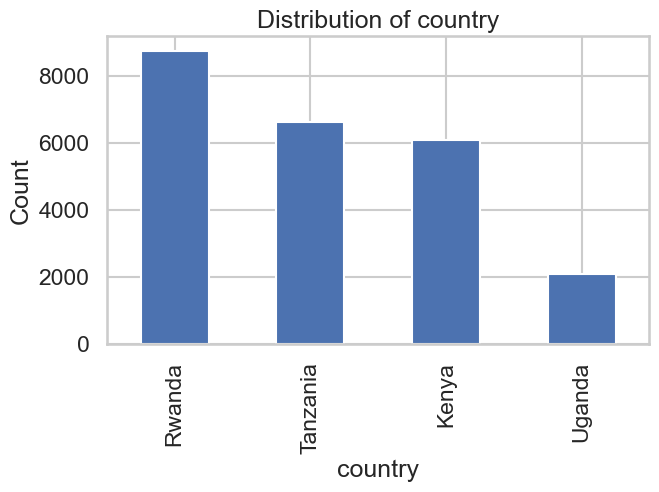

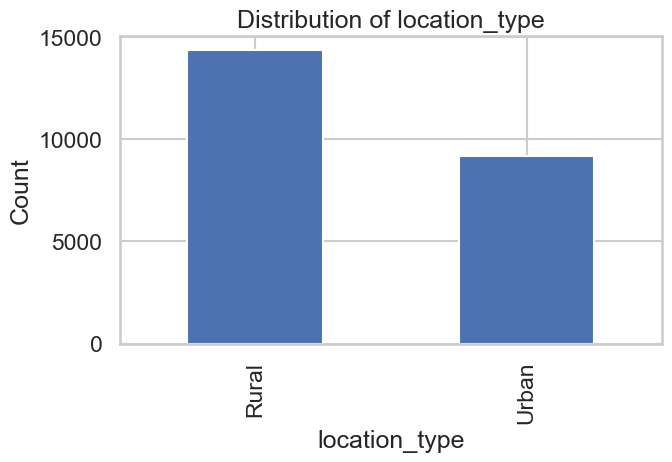

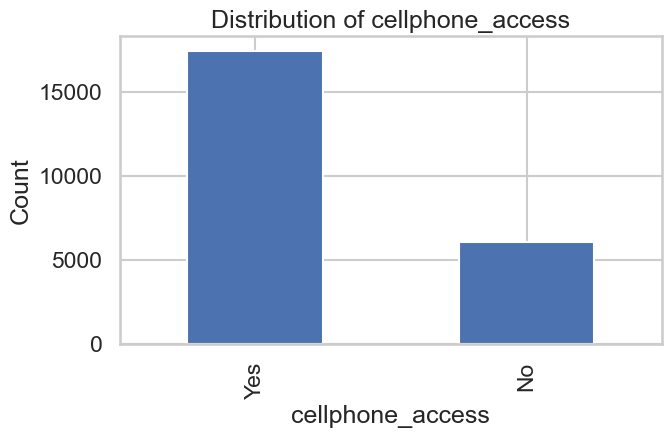

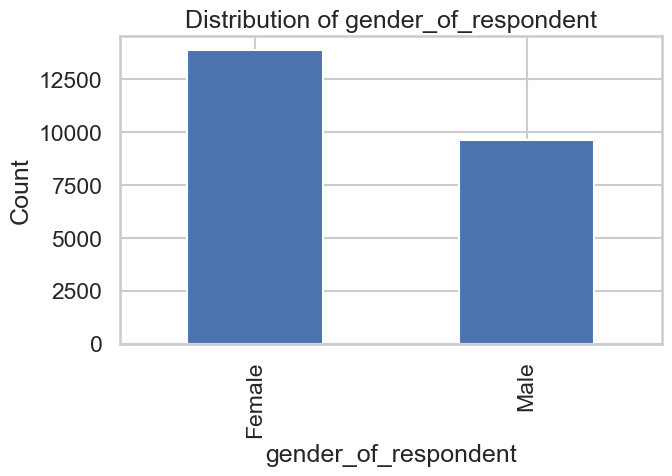

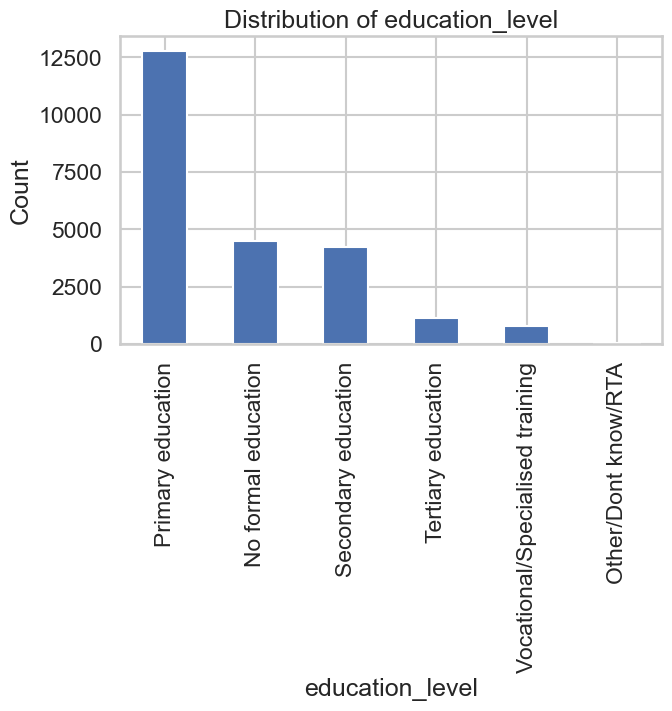

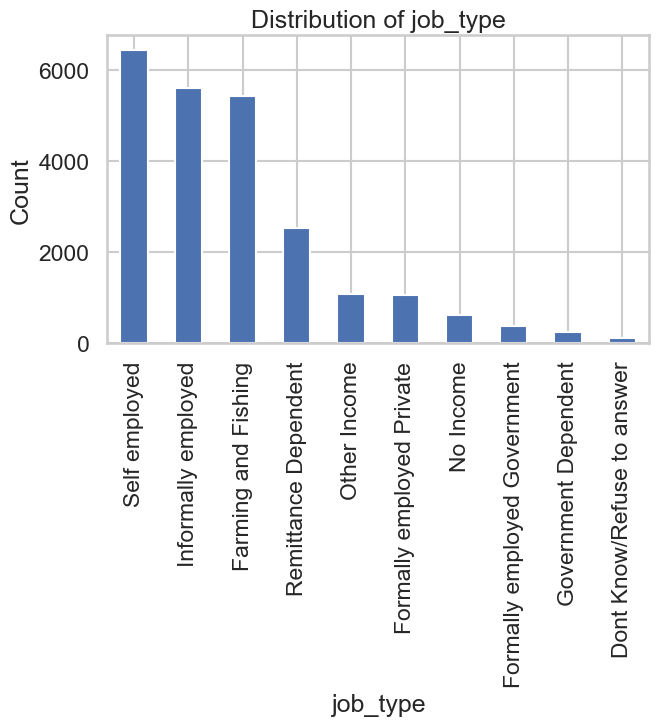

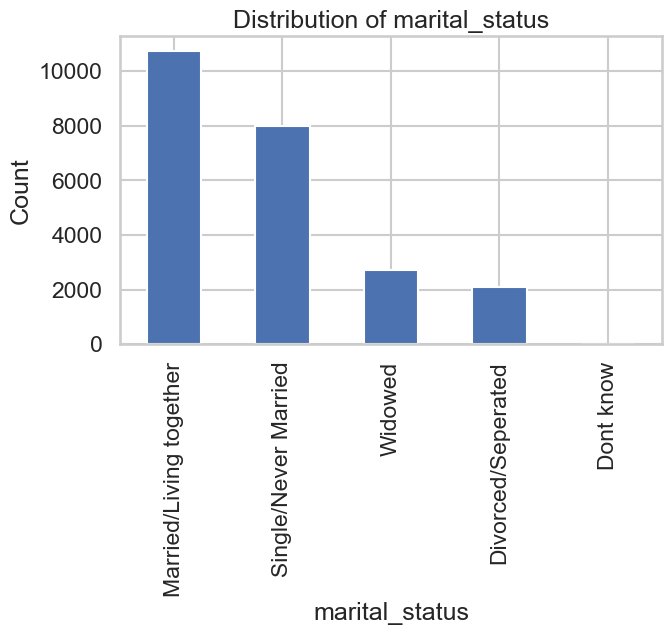

In [65]:
cat_cols = [
    'country', 'location_type', 'cellphone_access','gender_of_respondent',
    'education_level', 'job_type', 'marital_status'
]

for col in cat_cols:
    plt.figure(figsize=(7,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.ylabel("Count")
    plt.show()


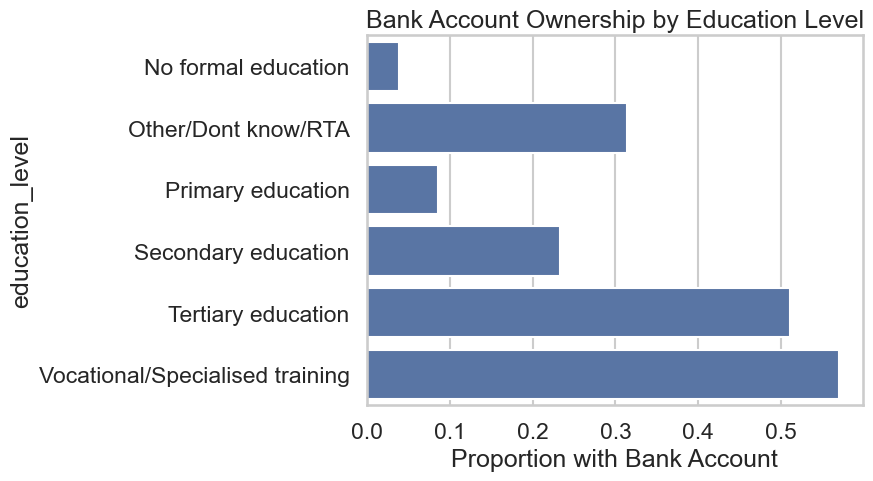

In [66]:
sns.barplot(
    x=df.groupby('education_level')['bank_account'].mean().values,
    y=df.groupby('education_level')['bank_account'].mean().index
)
plt.title("Bank Account Ownership by Education Level")
plt.xlabel("Proportion with Bank Account")
plt.show()
